In [2]:
import pandas as pd

In [3]:
# Carregar Dataframe com dados do Netflix
df_netflix = pd.read_csv('./datasets/netflix_daily_top_10.csv')

In [4]:
df_netflix.head()

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
0,2020-04-01,1,1,1,"Tiger King: Murder, Mayhem …",TV Show,Yes,"Mar 20, 2020",9,90
1,2020-04-01,2,2,-,Ozark,TV Show,Yes,"Jul 21, 2017",5,45
2,2020-04-01,3,3,2,All American,TV Show,NaN,"Mar 28, 2019",9,76
3,2020-04-01,4,4,-,Blood Father,Movie,NaN,"Mar 26, 2020",5,30
4,2020-04-01,5,5,4,The Platform,Movie,Yes,"Mar 20, 2020",9,55


In [5]:
df_netflix.tail()

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
7095,2022-03-11,6,5,1,Worst Roommate Ever,TV Show,Yes,"Mar 1, 2022",10,81
7096,2022-03-11,7,7,2,Vikings: Valhalla,TV Show,Yes,"Feb 25, 2022",14,100
7097,2022-03-11,8,8,-,Shooter,Movie,NaN,"Aug 1, 2014",3,7
7098,2022-03-11,9,9,7,Shrek 2,Movie,NaN,"Mar 1, 2022",10,33
7099,2022-03-11,10,10,-,Shrek,Movie,NaN,"May 1, 2018",7,12


Período da análise feita

In [19]:
import datetime as dt 

In [22]:
# Início
print(pd.to_datetime(df_netflix['As of']).dt.date.min())

2020-04-01


In [24]:
# Fim
print(pd.to_datetime(df_netflix['As of']).dt.date.max())

2022-03-11


In [ ]:
# Mostrar estrutura / schema do dataframe
df_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7100 entries, 0 to 7099
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   As of                 7100 non-null   object
 1   Rank                  7100 non-null   int64 
 2   Year to Date Rank     7100 non-null   object
 3   Last Week Rank        7100 non-null   object
 4   Title                 7100 non-null   object
 5   Type                  7100 non-null   object
 6   Netflix Exclusive     4599 non-null   object
 7   Netflix Release Date  7100 non-null   object
 8   Days In Top 10        7100 non-null   int64 
 9   Viewership Score      7100 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 554.8+ KB


In [25]:
# Visualização dos tipos de dados

df_netflix.dtypes

As of                   object
Rank                     int64
Year to Date Rank       object
Last Week Rank          object
Title                   object
Type                    object
NetflixExclusive        object
Netflix Release Date    object
Days In Top 10           int64
Viewership Score         int64
dtype: object

Tamanho da base de dados

In [ ]:
df_netflix.shape

(7100, 10)

In [14]:
# Detecção de valores ausentes
df_netflix.isna().sum()

As of                      0
Rank                       0
Year to Date Rank          0
Last Week Rank             0
Title                      0
Type                       0
Netflix Exclusive       2501
Netflix Release Date       0
Days In Top 10             0
Viewership Score           0
dtype: int64

In [17]:
# Renomear coluna
df_netflix.rename(columns={'Netflix Exclusive':'NetflixExclusive'},inplace=True)

In [18]:
df_netflix.NetflixExclusive.isna().sum()

np.int64(2501)

Detecção e Visualização de Outliers

In [ ]:
# Informações estatísticas
df_netflix.describe()

,Rank,Days In Top 10,Viewership Score
count,7100.000000,7100.000000,7100.000000
mean,5.500000,24.123662,122.790141
std,2.872484,58.473789,213.861642
min,1.000000,1.000000,1.000000
25%,3.000000,3.000000,19.000000
50%,5.500000,7.000000,50.000000
75%,8.000000,18.000000,128.000000
max,10.000000,428.000000,1474.000000


Rank                   Axes(0.125,0.11;0.227941x0.77)
Days In Top 10      Axes(0.398529,0.11;0.227941x0.77)
Viewership Score    Axes(0.672059,0.11;0.227941x0.77)
dtype: object

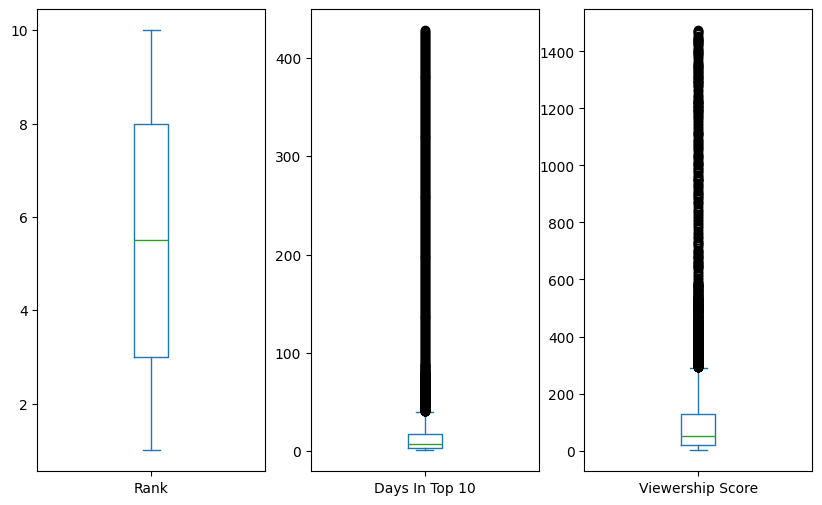

In [29]:
df_netflix.plot(kind='box',figsize=(10,6),subplots=True)

In [30]:
# Análise mais detalhada dos outliers

df_netflix[df_netflix['Days In Top 10'] >= 50]

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,NetflixExclusive,Netflix Release Date,Days In Top 10,Viewership Score
2209,2020-11-07,10,8,-,Cocomelon,TV Show,NaN,"Jun 1, 2020",50,114
2229,2020-11-09,10,-,-,Cocomelon,TV Show,NaN,"Jun 1, 2020",51,115
2235,2020-11-10,6,10,5,Cocomelon,TV Show,NaN,"Jun 1, 2020",52,120
2246,2020-11-11,7,6,5,Cocomelon,TV Show,NaN,"Jun 1, 2020",53,124
2256,2020-11-12,7,7,7,Cocomelon,TV Show,NaN,"Jun 1, 2020",54,128
...,...,...,...,...,...,...,...,...,...,...
6967,2022-02-26,8,5,8,Ozark,TV Show,Yes,"Jul 21, 2017",86,527
6979,2022-02-27,10,8,7,Ozark,TV Show,Yes,"Jul 21, 2017",87,528
6986,2022-02-28,7,10,7,Ozark,TV Show,Yes,"Jul 21, 2017",88,532
6996,2022-03-01,7,7,8,Ozark,TV Show,Yes,"Jul 21, 2017",89,536


In [ ]:
# Títulos com mais aparições no Top 10

df_netflix.Title.value_counts().head()

Title
Cocomelon               428
Ozark                    85
Cobra Kai                81
Manifest                 80
The Queenâs Gambit     73
Name: count, dtype: int64

In [ ]:
# Títulos com menos aparições no Top 10

df_netflix.Title.value_counts().tail()

Title
Elves                           1
Dark Shadows                    1
Scary Stories to Tell in th…    1
Uncorked                        1
Badland                         1
Name: count, dtype: int64

<Axes: >

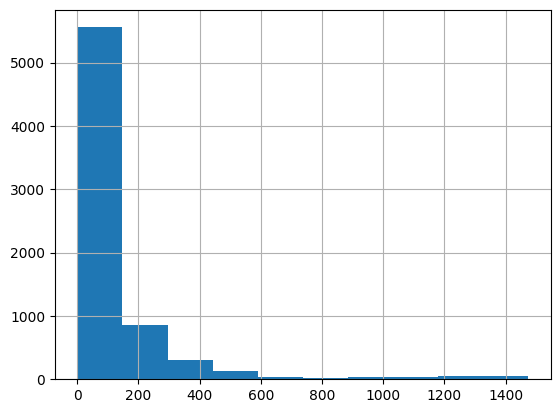

In [ ]:
# Visualização da distribuição do Viewership Score

df_netflix['Viewership Score'].hist()

In [ ]:
# Análise da distribuição do Viewership Score

df_netflix['Viewership Score'].describe()

count    7100.000000
mean      122.790141
std       213.861642
min         1.000000
25%        19.000000
50%        50.000000
75%       128.000000
max      1474.000000
Name: Viewership Score, dtype: float64

In [ ]:
# Informações sobre o título com maior Viewership Score

df_netflix.loc[df_netflix['Viewership Score'].idxmax()]

As of                    2022-03-01
Rank                              9
Year to Date Rank                 -
Last Week Rank                    -
Title                     Cocomelon
Type                        TV Show
NetflixExclusive                NaN
Netflix Release Date    Jun 1, 2020
Days In Top 10                  428
Viewership Score               1474
Name: 6998, dtype: object